# Explore The Data

## 1. Explore The Data Lable

In [ ]:
import pickle
DATA_PATH_PREFIX='/mnt/d/DataSets/WESAD'
SUBJECT_ID = 'S2'
try:
    with open(f"{DATA_PATH_PREFIX}/{SUBJECT_ID}/{SUBJECT_ID}.pkl", 'rb') as f:
        data = pickle.load(f, encoding="latin1")
        print(f"Data Load Successfully!")
except FileNotFoundError as e:
    print(f"Error:{e}")


Data Load Successfully!


In [ ]:
print("\n--- Data Structure Overview ---")
print(f"Keys in loaded data: {data.keys()}")


--- Data Structure Overview ---
Keys in loaded data: dict_keys(['signal', 'label', 'subject'])


In [ ]:
signal_data = data['signal']
print(f"Keys in signal: {signal_data.keys()}")

Keys in signal: dict_keys(['chest', 'wrist'])


In [ ]:
chest_data = signal_data['chest']
print(f"Keys in chest: {chest_data.keys()}")

Keys in chest: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [ ]:
# Extract ECG and labels
ecg_data = chest_data['ECG']
labels = data['label']

print(f"ECG signal shape: {ecg_data.shape}")
print(f"Labels shape: {labels.shape}")

emg_data = chest_data['EMG']
print(f"EMG signal shape: {emg_data.shape}")

eda_data = chest_data['EDA']
print(f"EDA signal shape: {eda_data.shape}")

temp_data = chest_data['Temp']
print(f"Temperature signal shape: {temp_data.shape}")

resp_data = chest_data['Resp']
print(f"Respiration signal shape: {resp_data.shape}")

acc_data = chest_data['ACC']
print(f"Accelerometer signal shape: {acc_data.shape}")

ECG signal shape: (4255300, 1)
Labels shape: (4255300,)
EMG signal shape: (4255300, 1)
EDA signal shape: (4255300, 1)
Temperature signal shape: (4255300, 1)
Respiration signal shape: (4255300, 1)
Accelerometer signal shape: (4255300, 3)


In [ ]:
wrist_data=signal_data['wrist']
print(f"Keys in wrist: {wrist_data.keys()}")

Keys in wrist: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


In [ ]:
bvp_data=wrist_data['BVP']
print(f"BVP signal shape: {bvp_data.shape}")
eda_data=wrist_data['EDA']
print(f"EDA signal shape: {eda_data.shape}")
temp_data=wrist_data['TEMP']
print(f"Temperature signal shape: {temp_data.shape}")
acc_data=wrist_data['ACC']
print(f"Acceleration signal shape: {acc_data.shape}")

BVP signal shape: (389056, 1)
EDA signal shape: (24316, 1)
Temperature signal shape: (24316, 1)
Acceleration signal shape: (194528, 3)


### Inspect the subject's label of the dataset

In [ ]:
SAMPLING_RATE_RESP = 700 # Hz (from WESAD documentation for RespiBAN ECG)
LABEL_SAMPLING_RATE = 700 # Hz (from WESAD documentation for labels)
HRV_INTERPOLATION_RATE = 4 # Hz (Common for HRV spectral analysis, as per RHRV example in the wavelet paper)
PLOT_TIME = 30 # seconds (for plotting)

In [ ]:
import numpy as np
unique_labels = np.unique(labels)
print(unique_labels)

# Count the number of samples for each label
lbl_cnt={}
for label in unique_labels:
    lbl_cnt = len(labels[labels==label])
    print(f"Label {label}: {lbl_cnt} samples")
    duration= lbl_cnt/SAMPLING_RATE_RESP
    print(f"Duration: {duration} seconds")
    lbl_cnt[label] = (lbl_cnt,duratioon)

## 2.Visualise the Raw Data

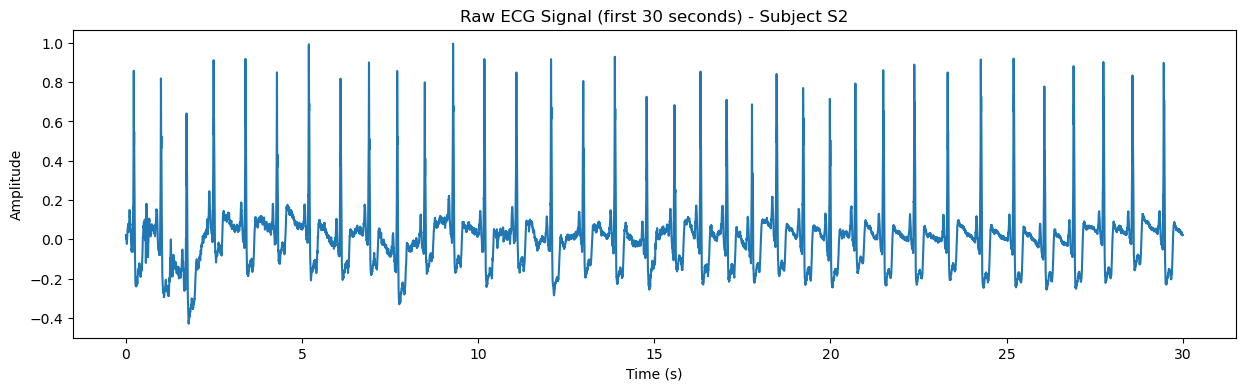

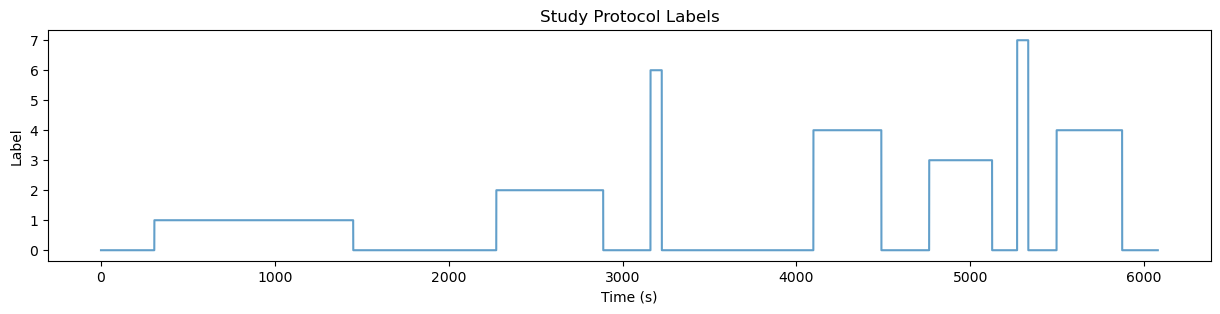

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 4))
plt.plot(np.arange(len(ecg_data[:SAMPLING_RATE_RESP*PLOT_TIME])) / SAMPLING_RATE_RESP, 
         ecg_data[:SAMPLING_RATE_RESP*PLOT_TIME])
plt.title(f'Raw ECG Signal (first {PLOT_TIME} seconds) - Subject {SUBJECT_ID}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(15, 3))
plt.plot(np.arange(len(labels)) / LABEL_SAMPLING_RATE, labels, alpha=0.7)
plt.title('Study Protocol Labels')
plt.xlabel('Time (s)')
plt.ylabel('Label')
plt.show()

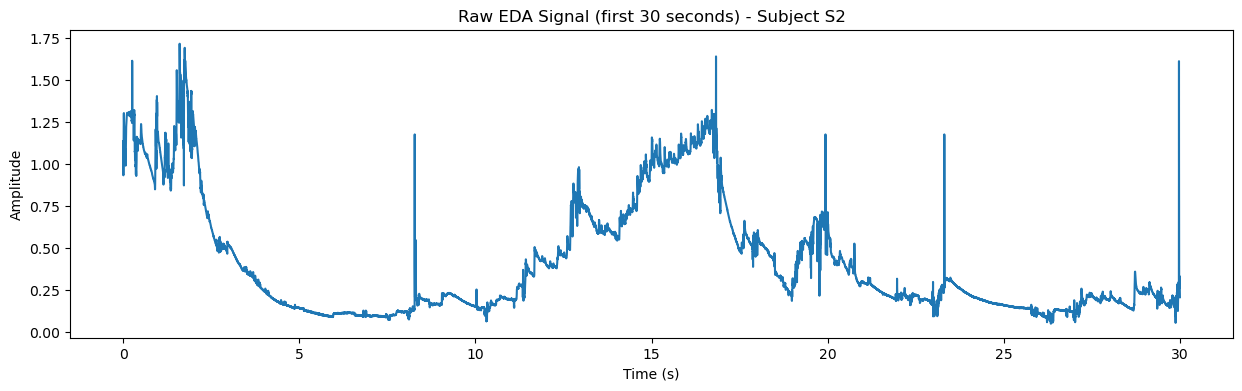

In [12]:
plt.figure(figsize=(15, 4))
plt.plot(np.arange(len(eda_data[:SAMPLING_RATE_RESP*PLOT_TIME])) / SAMPLING_RATE_RESP, 
         eda_data[:SAMPLING_RATE_RESP*PLOT_TIME])
plt.title(f'Raw EDA Signal (first {PLOT_TIME} seconds) - Subject {SUBJECT_ID}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

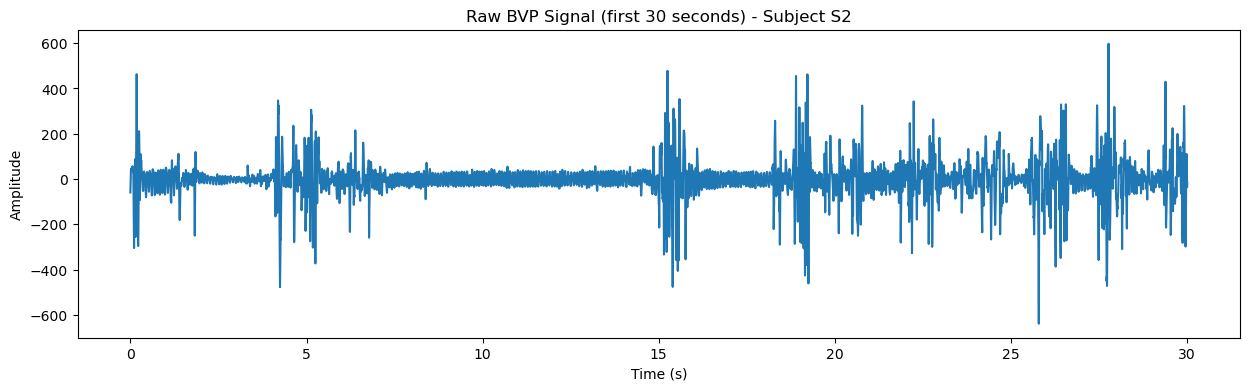

In [13]:
plt.figure(figsize=(15, 4))
plt.plot(np.arange(len(bvp_data[:SAMPLING_RATE_RESP*PLOT_TIME])) / SAMPLING_RATE_RESP, 
         bvp_data[:SAMPLING_RATE_RESP*PLOT_TIME])
plt.title(f'Raw BVP Signal (first {PLOT_TIME} seconds) - Subject {SUBJECT_ID}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

## Extract the RR Interval data from the ECG signal

In [14]:
import pandas as pd
import neurokit2 as nk
print("\n--- II. RR Interval Extraction from ECG ---")
print(f"Processing ECG signal of length {len(ecg_data)} samples at {SAMPLING_RATE_RESP} Hz...")

# Initialize variables to store results and defaults
rr_df = pd.DataFrame()
rpeaks_indices = np.array([])

try:
    # Clean ECG signal
    print("Cleaning ECG signal...")
    cleaned_ecg = nk.ecg_clean(ecg_data, sampling_rate=SAMPLING_RATE_RESP)

    # Detect R-peaks
    print("Detecting R-peaks...")
    _, rpeaks = nk.ecg_peaks(cleaned_ecg, sampling_rate=SAMPLING_RATE_RESP)

    # Extract R-peak indices
    rpeaks_indices = rpeaks['ECG_R_Peaks']
    print(f"R-peak indices: {rpeaks_indices[:5]}")
    print(f"Detected {len(rpeaks_indices)} R-peaks.")

    if len(rpeaks_indices) > 1:
        # Compute RR intervals in ms
        rr_intervals_ms = np.diff(rpeaks_indices) / SAMPLING_RATE_RESP * 1000
        rr_times_sec = rpeaks_indices[1:] / SAMPLING_RATE_RESP
        rr_df = pd.DataFrame({'RR_Intervals_ms': rr_intervals_ms, 'RR_Times_sec': rr_times_sec})
        print(f"Extracted {len(rr_intervals_ms)} RR intervals.")
        print(rr_df[:5])
    else:
        print("No RR intervals detected.")

except Exception as e:  
    print(f"Error: {e}")




--- II. RR Interval Extraction from ECG ---
Processing ECG signal of length 4255300 samples at 700 Hz...
Cleaning ECG signal...
Detecting R-peaks...
R-peak indices: [ 699 1208 1745 2378 3002]
Detected 7250 R-peaks.
Extracted 7249 RR intervals.
   RR_Intervals_ms  RR_Times_sec
0       727.142857      1.725714
1       767.142857      2.492857
2       904.285714      3.397143
3       891.428571      4.288571
4       907.142857      5.195714


## 3. Data Preprocessing

### 3.1 Unify the time axis of all signals: undersample the signals to the same frequence to 4Hz

In [ ]:
import scipy.signal as sg

duration = len(labels)* 1/SAMPLING_RATE_RESP
target_data_len = int(duration * HRV_INTERPOLATION_RATE)

bvp_resampled = sg.resample(bvp_data, target_data_len)
acc_resampled = sg.resample(acc_data, target_data_len, axis=0) if acc_data.ndim == 2 else sg.resample(acc_data, target_data_len)

eda_resampled = sg.resample(eda_data, target_data_len)
temp_resampled = sg.resample(temp_data, target_data_len)

labels_resampled = sg.resample(labels, target_data_len)
